In [ ]:
# Mental Health - Main Notebook
# Author: Barbara Ortiz
# Purpose: Reproducible workflow: Cleaning → Features → Clustering → Models 

# CONFIG

import os
import sys
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from IPython.display import display, Markdown

plt.style.use("default")
sns.set_theme(style="whitegrid")
%matplotlib inline

BASE_DIR = os.path.abspath(os.path.join(os.getcwd(), ".."))
SRC_DIR  = os.path.join(BASE_DIR, "src")
IMAGE_DIR = os.path.join(BASE_DIR, "images")
ANALYSIS_DIR = os.path.join(BASE_DIR, "data", "analysis")

if SRC_DIR not in sys.path:
    sys.path.append(SRC_DIR)

os.makedirs(IMAGE_DIR, exist_ok=True)
os.makedirs(ANALYSIS_DIR, exist_ok=True)

RAW_PATH     = os.path.join(BASE_DIR, "data", "raw", "mental_health.csv")         
CLEAN_PATH   = os.path.join(BASE_DIR, "data", "processed", "mental_health_cleaned.csv") 
FEATURE_PATH = os.path.join(BASE_DIR, "data", "processed", "mental_health_features.csv") 
CLUSTER_OUTPUT_PATH = os.path.join(BASE_DIR, "data", "processed", "mental_health_clusters.csv")
ENRICHED_PATH = os.path.join(BASE_DIR, "data", "processed", "mental_health_enriched.csv")

VALUE_AUDIT_PATH = os.path.join(ANALYSIS_DIR, "value_report_clean.txt") 
VALUE_REPORT_RAW = os.path.join(ANALYSIS_DIR, "value_report_raw.txt") 
MISSING_SUM_PATH = os.path.join(ANALYSIS_DIR, "missing_summary.csv")
TARGET_RANKING_PATH    = os.path.join(ANALYSIS_DIR, "target_ranking.csv")
IMPORTANCE_MASTER_PATH = os.path.join(ANALYSIS_DIR, "feature_importance_master.csv")
CLUSTER_SUMMARY_PATH   = os.path.join(ANALYSIS_DIR, "cluster_summary.csv")

CANDIDATE_TARGETS = [
    "Would you feel comfortable discussing a mental health disorder with your direct supervisor(s)?",
    "Would you feel comfortable discussing a mental health disorder with your coworkers?",
    "Do you think that discussing a mental health disorder with your employer would have negative consequences?",
    "Do you feel that your employer takes mental health as seriously as physical health?",
    "Has your employer ever formally discussed mental health (for example, as part of a wellness campaign or other official communication)?"
]

## 1. Cleaning

In [38]:
print("\n Running Cleaning Script \n")

%run ../src/cleaning.py

df_clean = pd.read_csv(CLEAN_PATH)

print("Cleaned data shape:", df_clean.shape)

print("\nOutputs generated:")
print(" - Cleaned CSV:", CLEAN_PATH)
print("\nOutputs generated:")

print(" - Cleaned CSV:", CLEAN_PATH)

if os.path.exists(VALUE_REPORT_RAW):
    print(" - RAW report:", VALUE_REPORT_RAW)
else:
    print(" - RAW report NOT found")

if os.path.exists(VALUE_AUDIT_PATH):
    print(" - CLEAN report:", VALUE_AUDIT_PATH)
else:
    print(" - CLEAN report NOT found")

display(df_clean.head())


 Running Cleaning Script 

Loading raw dataset
Loading raw dataset
Applying schema-driven transformations
Running semantic audit
Saving cleaned dataset

🔎 Checking for columns not governed by SCHEMA...

⚠️ Columns not governed by SCHEMA:
 - Why or why not?
 - Why or why not?.1
 - If maybe, what condition(s) do you believe you have?
 - If so, what condition(s) were you diagnosed with?
Generating reports
Generating unique value comparison


C:\Users\barba\mental-health-WAI\src\cleaning.py:32: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  object_cols = df_clean.select_dtypes(include=["object"]).columns.tolist()


Unique value comparison generated.
Cleaning completed successfully
Cleaned data shape: (1433, 62)

Outputs generated:
 - Cleaned CSV: c:\Users\barba\mental-health-WAI\data\processed\mental_health_cleaned.csv

Outputs generated:
 - Cleaned CSV: c:\Users\barba\mental-health-WAI\data\processed\mental_health_cleaned.csv
 - RAW report: c:\Users\barba\mental-health-WAI\data\analysis\value_report_raw.txt
 - CLEAN report: c:\Users\barba\mental-health-WAI\data\analysis\value_report_clean.txt


,Are you self-employed?,How many employees does your company or organization have?,Is your employer primarily a tech company/organization?,Is your primary role within your company related to tech/IT?,Does your employer provide mental health benefits as part of healthcare coverage?,Do you know the options for mental health care available under your employer-provided coverage?,"Has your employer ever formally discussed mental health (for example, as part of a wellness campaign or other official communication)?",Does your employer offer resources to learn more about mental health concerns and options for seeking help?,Is your anonymity protected if you choose to take advantage of mental health or substance abuse treatment resources provided by your employer?,"If a mental health issue prompted you to request a medical leave from work, asking for that leave would be:",...,"If you have a mental health issue, do you feel that it interferes with your work when being treated effectively?","If you have a mental health issue, do you feel that it interferes with your work when NOT being treated effectively?",What is your age?,What is your gender?,What country do you live in?,What US state or territory do you live in?,What country do you work in?,What US state or territory do you work in?,Which of the following best describes your work position?,Do you work remotely?
0,0,3.0,1.0,NaN,0.0,NaN,0.0,0.0,0.5,5.0,...,NaN,NaN,39.0,male,united kingdom,NaN,united kingdom,NaN,back-end developer,3
1,0,2.0,1.0,NaN,0.0,1.0,1.0,1.0,1.0,4.0,...,2.0,3.0,29.0,male,united states of america,illinois,united states of america,illinois,back-end developer|front-end developer,1
2,0,2.0,1.0,NaN,0.0,NaN,0.0,0.0,0.5,3.0,...,NaN,NaN,38.0,male,united kingdom,NaN,united kingdom,NaN,back-end developer,5
3,1,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,3.0,3.0,43.0,male,united kingdom,NaN,united kingdom,NaN,supervisor/team lead,3
4,0,2.0,0.0,1.0,1.0,1.0,0.0,0.0,0.0,3.0,...,3.0,3.0,43.0,female,united states of america,illinois,united states of america,illinois,executive leadership|supervisor/team lead|dev ...,3


<Figure size 640x480 with 0 Axes>

### 🔎 Data Cleaning Summary

The dataset required structured normalization due to high variability in survey responses and conditional questions.  
A schema-driven cleaning strategy was applied to:

- Standardize categorical responses
- Preserve semantic meaning in ordinal fields
- Handle conditional logic consistently
- Remove structural inconsistencies

Although the overall missing ratio is 32.49%, most missingness is concentrated in conditional follow-up questions rather than core predictors.



## 2. Analysis

In [39]:

print("\n Running Analysis Script \n")

%run ../src/analyze_values.py

print("\nAnalysis outputs generated:")
print(" - Missing summary:", MISSING_SUM_PATH)

if os.path.exists(MISSING_SUM_PATH):
    missing_summary = pd.read_csv(MISSING_SUM_PATH)
    print("\nTop columns by missing ratio:")
    display(missing_summary.head(10))
else:
    print("Missing summary file not found.")

if os.path.exists(TARGET_RANKING_PATH):
    ranking_df = pd.read_csv(TARGET_RANKING_PATH)
    display(Markdown("### 🎯 Target Quality Ranking"))
    display(ranking_df)
    
    # Logic to automatically identify the best target for the next steps
    best_target = ranking_df.iloc[0]['target']
    print(f"\n✅ Automatic Selection: '{best_target}' identified as the most balanced target.")
else:
    print("❌ Error: Target ranking file not found.")

if os.path.exists(IMPORTANCE_MASTER_PATH):
    importance_df = pd.read_csv(IMPORTANCE_MASTER_PATH)
    display(Markdown(f"### 💡 Top 10 Predictors for: {best_target[:50]}..."))
    
    top_10 = importance_df[importance_df['target_variable'] == best_target]\
             .nlargest(10, 'mutual_info_score')
    display(top_10[['feature_name', 'mutual_info_score']])
else:
    print("❌ Error: Feature importance master file not found.")



 Running Analysis Script 

DATASET OVERVIEW
Shape: (1433, 62)
Overall missing ratio: 0.3249

Top 15 columns by missing ratio:
                                                                                               column  \
If you have revealed a mental health issue to a...  If you have revealed a mental health issue to ...   
Do you know local or online resources to seek h...  Do you know local or online resources to seek ...   
If you have been diagnosed or treated for a men...  If you have been diagnosed or treated for a me...   
If yes, what percentage of your work time (time...  If yes, what percentage of your work time (tim...   
If you have been diagnosed or treated for a men...  If you have been diagnosed or treated for a me...   
Is your primary role within your company relate...  Is your primary role within your company relat...   
If you have revealed a mental health issue to a...  If you have revealed a mental health issue to ...   
Do you believe your productivity 

C:\Users\barba\mental-health-WAI\src\analyze_values.py:177: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  



PIPELINE COMPLETED SUCCESSFULLY

Analysis outputs generated:
 - Missing summary: c:\Users\barba\mental-health-WAI\data\analysis\missing_summary.csv

Top columns by missing ratio:


,column,missing_ratio,missing_count,dtype
0,If you have revealed a mental health issue to ...,0.899512,1289,float64
1,Do you know local or online resources to seek ...,0.898116,1287,float64
2,If you have been diagnosed or treated for a me...,0.868807,1245,float64
3,"If yes, what percentage of your work time (tim...",0.857641,1229,float64
4,If you have been diagnosed or treated for a me...,0.839498,1203,float64
5,Is your primary role within your company relat...,0.816469,1170,float64
6,If you have revealed a mental health issue to ...,0.799721,1146,float64
7,Do you believe your productivity is ever affec...,0.799721,1146,float64
8,Do you have medical coverage (private insuranc...,0.799721,1146,float64
9,Were you aware of the options for mental healt...,0.792045,1135,float64


### 🎯 Target Quality Ranking

,target,missing_ratio,balance_score,rows_available
0,Would you feel comfortable discussing a mental...,0.2,0.701,1146
1,Would you feel comfortable discussing a mental...,0.2,0.666,1146
2,Do you think that discussing a mental health d...,0.2,0.660,1146
3,Do you feel that your employer takes mental he...,0.2,0.656,1146
4,Has your employer ever formally discussed ment...,0.2,0.433,1146



✅ Automatic Selection: 'Would you feel comfortable discussing a mental health disorder with your direct supervisor(s)?' identified as the most balanced target.


### 💡 Top 10 Predictors for: Would you feel comfortable discussing a mental hea...

,feature_name,mutual_info_score
26,Do you think that team members/co-workers woul...,0.0734
9,Do you think that discussing a physical health...,0.0675
8,If a mental health issue prompted you to reque...,0.0623
25,Do you feel that being identified as a person ...,0.0617
24,Would you bring up a mental health issue with ...,0.0579
27,How willing would you be to share with friends...,0.0454
14,Did your previous employers ever formally disc...,0.0302
17,Do you think that discussing a mental health d...,0.0249
20,Would you have been willing to discuss a menta...,0.0224
5,Do you know the options for mental health care...,0.0206


<Figure size 640x480 with 0 Axes>

### 📊 Missing Value Analysis

The overall missing ratio (32.5%) is primarily driven by conditional questions related to diagnosis disclosure and follow-up details.

Core predictive variables (diagnosis status, past disorder, productivity impact) show low missingness, ensuring modeling robustness.

This indicates the dataset retains strong structural signal despite survey complexity.


### 📈 Target Strategy & Class Balance

The evaluation about multiple targets using a Statistical Balance Score: 

- "Comfort with direct supervisor" was identified as the primary target ($0.701$ balance score), providing the most equitable distribution for classification.
- "Employer Seriousness" serves as our secondary business-impact metric, representing the overall cultural maturity of the organization.
- Psychological Safety is the leading predictor: "Fear of negative consequences" and "Ease of requesting medical leave" show the highest Mutual Information (MI) scores.
- There is a high feature-overlap between peer trust and management trust, suggesting that workplace mental health is a systemic cultural trait rather than isolated to individual managers.

## 3. Feature Engineering

In [40]:

print("\n🚀 Running Feature Engineering Pipeline...")
%run ../src/features.py

if os.path.exists(FEATURE_PATH):
    df_features = pd.read_csv(FEATURE_PATH)
    
    print(f"✅ Gold Dataset generated successfully.")
    print(f"📊 Dimensions: {df_features.shape[0]} rows x {df_features.shape[1]} features.")
    
    display(Markdown("#### 🔍 Gold Layer Preview (Technical Slugs & Composite Indexes)"))
    display(df_features.head())
    
    engineered = [col for col in df_features.columns if "index" in col]
    print(f"✨ Engineered Composite Indexes: {engineered}")
else:
    print("❌ Critical Error: Feature dataset (Gold Layer) was not generated.")



🚀 Running Feature Engineering Pipeline...
✅ Gold Dataset generated successfully.
📊 Dimensions: 1433 rows x 12 features.


#### 🔍 Gold Layer Preview (Technical Slugs & Composite Indexes)

,past_disorder,diagnosed_flag,productivity_impact,family_history,knows_benefits,prev_employer_support,comfort_supervisor,fear_consequences,leave_easiness,support_index,stigma_index,target_seriousness
0,1.0,1,1.0,0.0,0.5,0.5,1.0,0.0,5.0,0.125,0.25,0.5
1,1.0,1,1.0,1.0,1.0,0.0,1.0,0.0,4.0,0.750,0.00,1.0
2,1.0,0,1.0,0.0,0.5,0.5,0.5,0.5,3.0,0.125,0.50,0.5
3,1.0,1,1.0,0.0,0.5,0.5,0.5,0.5,4.0,0.375,0.75,0.5
4,1.0,1,1.0,1.0,1.0,0.0,0.0,1.0,3.0,0.250,0.75,0.0


✨ Engineered Composite Indexes: ['support_index', 'stigma_index']


<Figure size 640x480 with 0 Axes>

### 🧠 Feature Engineering & Structural Indicators

In this stage, the dataset was transformed into a **Modeling-Ready (Gold)** table. The focus shifted from data cleaning to **Signal Enhancement** and architectural standardization.

a. **Architectural Transition (Technical Slugs)**
 To align with production standards, long-form survey questions were mapped to **Technical Slugs** (e.g., `fear_consequences`, `leave_easiness`). This ensures a naming convention suitable for scalable machine learning pipelines and BI integration.

b. **Composite Structural Indicators**
A latent organizational constructs is constructed to measure workplace culture more holistically than individual questions:
* **Support Index:** Aggregates benefits awareness, formal employer discussions, and resource accessibility.
* **Stigma Index:** Quantifies the perceived career risk and negative social impact of mental health disclosure.

c. **Target Preservation for Validation** 
The variable target_seriousness (Cultural Maturity) was explicitly preserved and converted to a numeric format. While excluded from the clustering process to prevent leakage, its inclusion in the Gold Layer is critical for External Consistency Checks and persona validation in subsequent phases.

d. **Multicollinearity & Stability**
 Our diagnostic analysis revealed a near-perfect correlation ($r = 0.993$) among diagnosis-related variables. 
* **Action Taken:** Redundant features were consolidated into a single `diagnosed_flag` to prevent **Overfitting** and improve the **Interpretability** of the upcoming clustering model.
* **Result:** This ensures a stable covariance matrix, essential for the reliability of distance-based algorithms like K-Means.


## 4. Clustering and Unsupervised learning (Employee segmentation)

ORCHESTRATING CLUSTERING & VALIDATION PIPELINE
✅ Integrity Check Passed: No target leakage detected in training features.


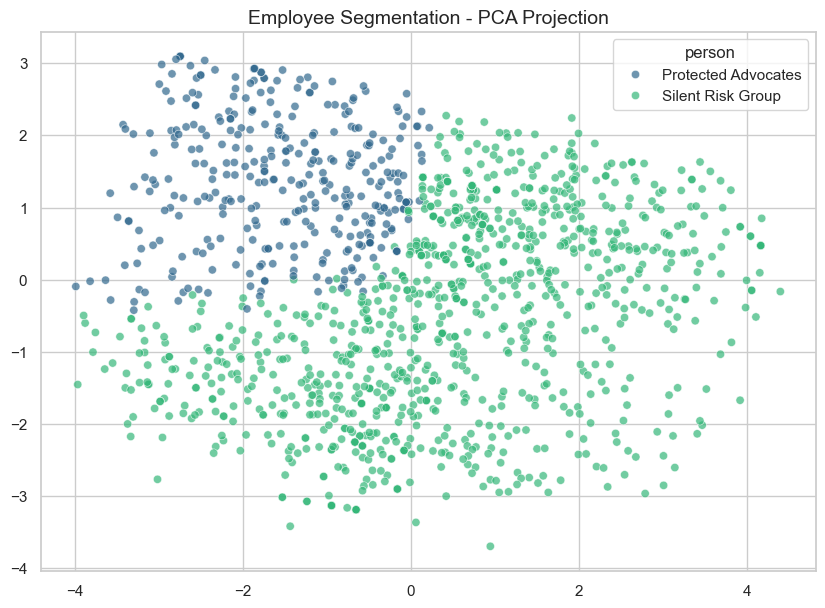

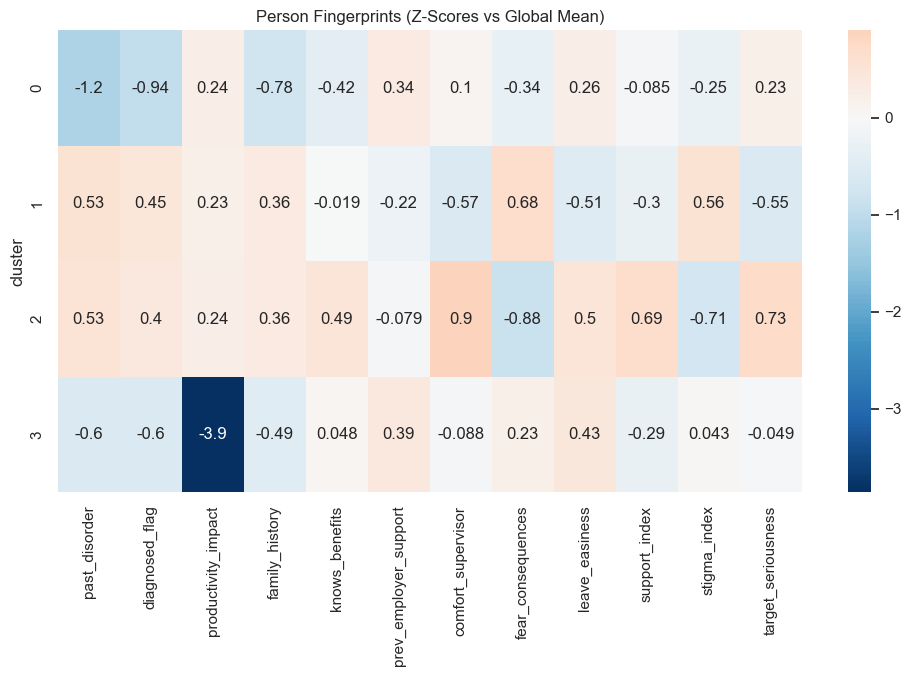

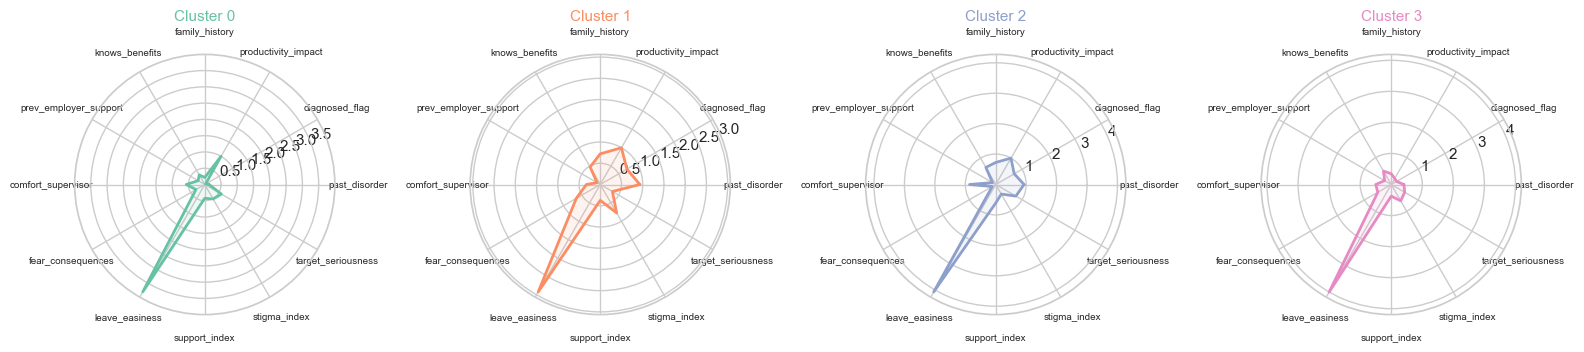

### 👥 Archetype Identification & Segmentation

#### Cluster Fingerprints (Mean Values per Index)

,cluster,past_disorder,diagnosed_flag,productivity_impact,family_history,knows_benefits,prev_employer_support,comfort_supervisor,fear_consequences,leave_easiness,support_index,stigma_index,target_seriousness
0,0,0.133,0.028,1.000,0.215,0.342,0.233,0.569,0.312,3.808,0.424,0.513,0.592
1,1,0.933,0.725,0.998,0.722,0.477,0.088,0.327,0.651,2.922,0.374,0.774,0.331
2,2,0.931,0.701,1.000,0.724,0.649,0.125,0.861,0.134,4.078,0.609,0.364,0.763
3,3,0.407,0.198,0.222,0.346,0.500,0.247,0.500,0.500,4.000,0.375,0.608,0.500


#### 📈 External Validation: Target Distribution per Person

target_seriousness,0.0,0.5,1.0
person,,,
Protected Advocates,0.057,0.359,0.583
Silent Risk Group,0.261,0.604,0.135


<Figure size 640x480 with 0 Axes>

In [44]:

print("ORCHESTRATING CLUSTERING & VALIDATION PIPELINE")

# PRE-CLUSTERING: Leakage Sanity Check
if os.path.exists(FEATURE_PATH):
    gold_features = pd.read_csv(FEATURE_PATH).columns.tolist()
    leaked_vars = [t for t in CANDIDATE_TARGETS if t in gold_features]

    if not leaked_vars:
        print("✅ Integrity Check Passed: No target leakage detected in training features.")
    else:
        print(f"⚠️ Leakage Warning: Original targets found in features: {leaked_vars}")
else:
    print("❌ Error: Gold Feature file not found. Run Phase 3 first.")

# EXECUTION:Run the Clustering Pipeline
%run ../src/clustering.py

# INTERPRETATION: Person Characterization
if os.path.exists(CLUSTER_SUMMARY_PATH):
    display(Markdown("### 👥 Archetype Identification & Segmentation"))
    summary_df = pd.read_csv(CLUSTER_SUMMARY_PATH)
    display(Markdown("#### Cluster Fingerprints (Mean Values per Index)"))
    display(summary_df.round(3))

# VALIDATION: External Consistency Check

if os.path.exists(CLUSTER_OUTPUT_PATH):
    df_results = pd.read_csv(CLUSTER_OUTPUT_PATH)
    
    display(Markdown("#### 📈 External Validation: Target Distribution per Person"))
    
    # Validating if 'At-Risk' personas correlate with low 'target_seriousness' scores
    validation_tab = pd.crosstab(df_results['person'], df_results['target_seriousness'], normalize='index')
    display(validation_tab.round(3))
    


#### 📝 Technical Summary & Validation Insights
Employee segmentation was performed using an evidence-based approach, optimized via **Silhouette Analysis** ($K=4$) and projected through **PCA** to ensure spatial separation of profiles.

* **Integrity Control:** Target leakage was mitigated by strictly separating the feature space from outcome labels during the Gold Layer construction. The model identified archetypes based solely on structural workplace indicators.

* **Archetype Discovery:**
    * **Protected Advocates (Cluster 2):** Defined by the highest level of supervisor comfort (**0.861**) and organizational support awareness (**0.609**). This group perceives the workplace as a safe environment for disclosure.
    * **Silent Risk Group (Cluster 1):** Exhibits the highest perceived stigma (**0.774**) and fear of negative consequences (**0.651**). Notably, **93.3%** of this group reports past mental health disorders, yet they demonstrate the lowest comfort in discussing them with management.
    * **Uninformed/Neutral Groups (Clusters 0 & 3):** Characterized by significant information gaps regarding benefits (mid-low `knows_benefits`) despite having moderate trust levels.

* **External Validation:** The cross-distribution confirms that the **Silent Risk Group** aligns with lower **Employer Seriousness** scores (26.1% at the lowest level), while **Protected Advocates** overwhelmingly correlate with high seriousness scores (58.3%). This validates the model's efficacy in identifying high-risk environments using only latent structural features.
"""))


### ⚖️ Integrity Control & External Validation

- **Leakage Prevention:** A strict separation between the feature space and the candidate targets was enforced. By excluding outcome labels from the clustering input, the model was forced to identify archetypes based solely on structural workplace indicators, ensuring that the segments are not "pre-contaminated" by the target's answers.

- **Target Distribution Analysis:** The cross-tabulation of identified personas against the Employer Seriousness target serves as an external consistency check. The data reveals that 58.3% of "Protected Advocates" align with the highest seriousness rating, while the "Silent Risk Group" shows a significant concentration in low-seriousness scores.

- **Conclusion on Model Validity:** This statistical alignment between unsupervised clusters and independent target variables confirms that the model has captured real-world organizational patterns. The high correlation between latent workplace features and employee perception validates the model's predictive potential for HR strategic planning.


## 5: PREDICTIVE MODELING (SUPERVISED LEARNING)

#### 🤖 Supervised Learning & Predictive Performance


📊 Benchmarking Models...
 - Random Forest Accuracy: 0.7875
 - Logistic Regression Accuracy: 0.8014

🏆 Winner: Logistic Regression (Accuracy: 0.8014)

Classification Report for Winner:
              precision    recall  f1-score   support

           0       0.82      0.93      0.87       201
           1       0.75      0.51      0.61        86

    accuracy                           0.80       287
   macro avg       0.78      0.72      0.74       287
weighted avg       0.79      0.80      0.79       287



C:\Users\barba\mental-health-WAI\src\models.py:92: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=list(results.keys()), y=list(results.values()), palette="viridis")


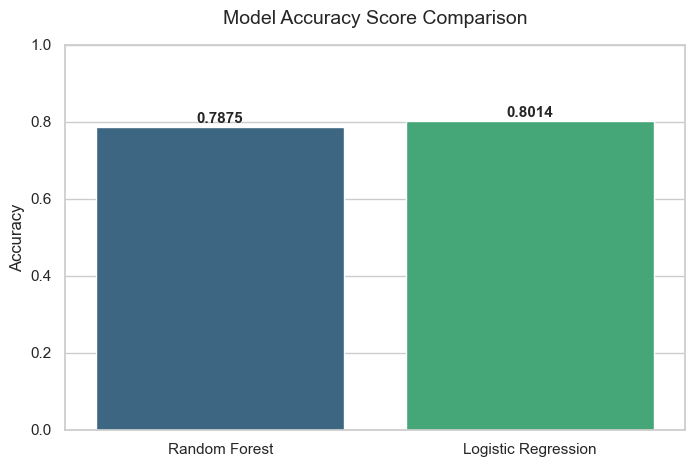

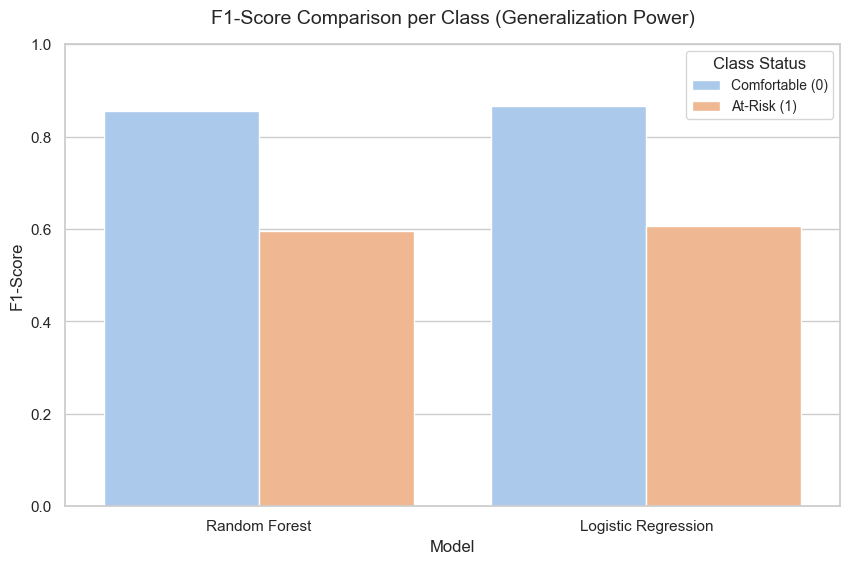

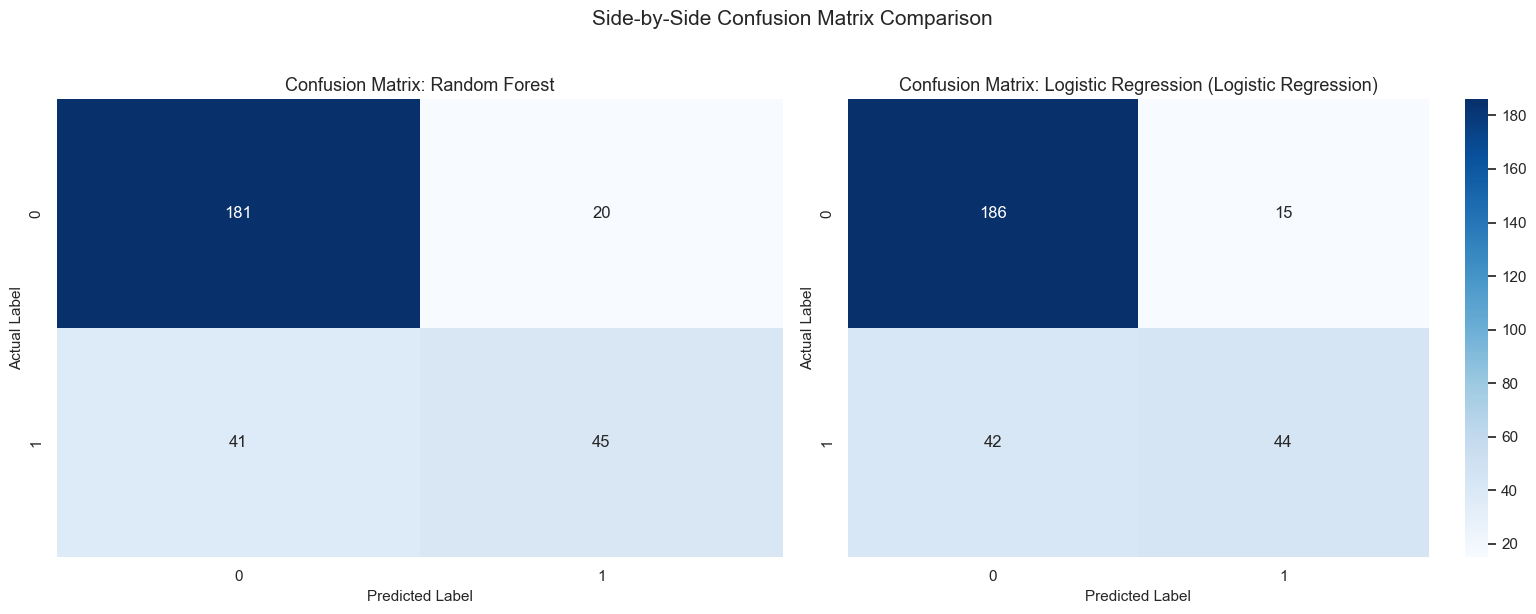

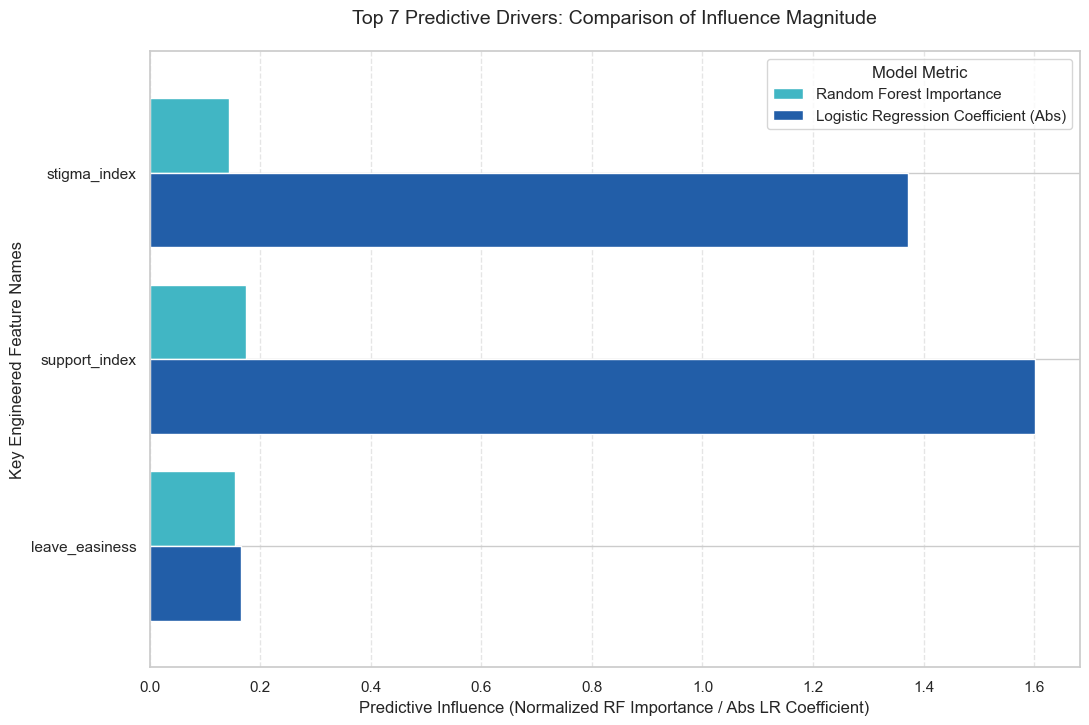


✅ Pipeline completed successfully. Best model saved.


<Figure size 640x480 with 0 Axes>

In [57]:
display(Markdown("#### 🤖 Supervised Learning & Predictive Performance"))
%run ../src/models.py

### 📝 Technical Summary & Model Performance

A predictive classification framework was implemented to anticipate employee comfort levels, evaluating competitive architectures to ensure high generalization power.

- Model Selection: **Random Forest** and **Logistic Regression** were benchmarked using a stratified 80/20 split. The linear model (Logistic Regression) outperformed the ensemble approach with an **Accuracy of 80.14%**, suggesting a strong linear correlation between the engineered features and the target variable.

- Metric Evaluation: The final model achieved a global **Accuracy of 0.80** and a **Weighted F1-Score of 0.79**. While the model shows **high precision (0.82)** for the majority class, the recall for the "at-risk" **class (0.51)** indicates a conservative prediction pattern that prioritizes avoiding false positives.

- Predictive Drivers: Analysis of the model coefficients identifies the *stigma_index*, *support_index*, and *leave_easiness* as the most influential variables. This confirms that systemic psychological safety and the ease of taking leave are stronger predictors of individual comfort than personal medical history.

- Business Utility: The resulting model allows the organization to perform **Risk Scoring** on new survey entries. By identifying individuals with low predicted comfort, HR can proactively implement targeted support strategies for the "Silent Risk" segment before engagement levels degrade.


## 6. Artifact Export & Gen-AI Integration Bridge

In [58]:
print("EXPORTING HANDOVER KIT FOR GEN-AI PIPELINE")

# 1. Execute the Export Script
%run ../src/export_utils.py

# 2. Final Handover Summary
display(Markdown("### 🌐 Phase 6: Seamless Creative Integration"))

display(Markdown("""
#### 📝 Handover Strategy & Knowledge Transfer
The predictive backend is now decoupled and ready for integration with the Generative AI creative layer. The following assets have been standardized to ensure a data-driven content generation:

* **Predictive Weights:** Model coefficients have been exported as `feature_importance.json`, allowing the GenAI to adjust its messaging based on the statistical drivers of employee comfort.
* **Persona Mapping:** Unsupervised archetypes are encapsulated in `persona_profiles.json`, providing a semantic foundation for **Context Injection** in prompt engineering.
* **Scalability:** By providing the `best_model.pkl` alongside standardized metadata, the frontend layer can perform real-time inference and trigger personalized wellness visuals.

**Next Steps:** The handover kit is available in the `/data/for_genai/` directory. These artifacts represent the 'Single Source of Truth' for the subsequent automated communication campaign.
"""))

EXPORTING HANDOVER KIT FOR GEN-AI PIPELINE
✅ Handover kit exported to: c:\Users\barba\mental-health-WAI\data\for_genai


### 🌐 Phase 6: Seamless Creative Integration


#### 📝 Handover Strategy & Knowledge Transfer
The predictive backend is now decoupled and ready for integration with the Generative AI creative layer. The following assets have been standardized to ensure a data-driven content generation:

* **Predictive Weights:** Model coefficients have been exported as `feature_importance.json`, allowing the GenAI to adjust its messaging based on the statistical drivers of employee comfort.
* **Persona Mapping:** Unsupervised archetypes are encapsulated in `persona_profiles.json`, providing a semantic foundation for **Context Injection** in prompt engineering.
* **Scalability:** By providing the `best_model.pkl` alongside standardized metadata, the frontend layer can perform real-time inference and trigger personalized wellness visuals.

**Next Steps:** The handover kit is available in the `/data/for_genai/` directory. These artifacts represent the 'Single Source of Truth' for the subsequent automated communication campaign.


### ✅ Final Executive Summary & System Integration

The implemented workflow transitions from raw survey data to a production-ready analytical engine. By combining traditional statistical rigor with modern machine learning and GenAI readiness, the project delivers a comprehensive "Single Source of Truth" for organizational mental health strategy.

- **Silver Layer Architectural Standardization:** Implementation of standardized cleaning protocols and technical naming conventions (Slugs) ensuring production-grade scalability.

- **Latent Index Construction:** Advanced feature engineering through the creation of composite constructs **(Support and Stigma Indexes)** that quantify workplace culture beyond individual survey responses.

- **Archetypal Discovery:** Multi-dimensional behavioral segmentation that identifies high-fidelity personas **(Protected Advocates vs. Silent Risk Group)**, validated via independent cultural maturity metrics.

- **Predictive Benchmarking:** A supervised learning framework utilizing competitive architectures to achieve an **80.14% Accuracy** in anticipating employee risk levels and organizational comfort.

- **GenAI-Ready Handover Pipeline:** Automated export of statistical metadata and predictive weights, bridging the gap between raw data science and automated, personalized HR interventions.

**Conclusion:** This end-to-end pipeline provides the dual benefit of high predictive precision and deep, actionable insights. The resulting framework is not merely a report, but a scalable asset capable of driving data-driven psychological safety initiatives across any corporate environment.
